In [97]:
import pandas as pd
df = pd.read_csv('merged_financial_data_news.csv')
print('CSV file loaded successfully into DataFrame named `df`.')
print(df.head())

CSV file loaded successfully into DataFrame named `df`.
         Date      Ticker     Open     High      Low    Close  Adj Close  \
0  2023-01-02    adanient  3870.00  3874.00  3822.55  3841.20    3835.94   
1  2023-01-02  adaniports   823.00   826.75   816.30   822.30     809.38   
2  2023-01-02  apollohosp  4488.00  4516.70  4446.00  4454.35    4411.58   
3  2023-01-02  asianpaint  3087.90  3087.90  3021.00  3047.25    2955.81   
4  2023-01-02    axisbank   932.25   945.00   931.80   941.60     939.11   

    Volume        date                                       cleaned_news  \
0   923051  2023-01-02  indian equity index ended monday session green...   
1  2042294  2023-01-02  indian equity index ended monday session green...   
2   246577  2023-01-02  indian equity index ended monday session green...   
3  1015990  2023-01-02  indian equity index ended monday session green...   
4  3498198  2023-01-02  indian equity index ended monday session green...   

   cleaned_news_len  neg

In [98]:
from sklearn.preprocessing import MinMaxScaler

# Enumerate the 'Ticker' column
df['ticker_enumerated'], unique_tickers = pd.factorize(df['Ticker'])

# Scale the enumerated 'Ticker' values between 0 and 1
scaler = MinMaxScaler()
df['ticker_scaled'] = scaler.fit_transform(df[['ticker_enumerated']])

print("Enumerated Ticker values and scaled values created successfully.")
print(df[['Ticker', 'ticker_enumerated', 'ticker_scaled']].head())

Enumerated Ticker values and scaled values created successfully.
       Ticker  ticker_enumerated  ticker_scaled
0    adanient                  0       0.000000
1  adaniports                  1       0.020408
2  apollohosp                  2       0.040816
3  asianpaint                  3       0.061224
4    axisbank                  4       0.081633


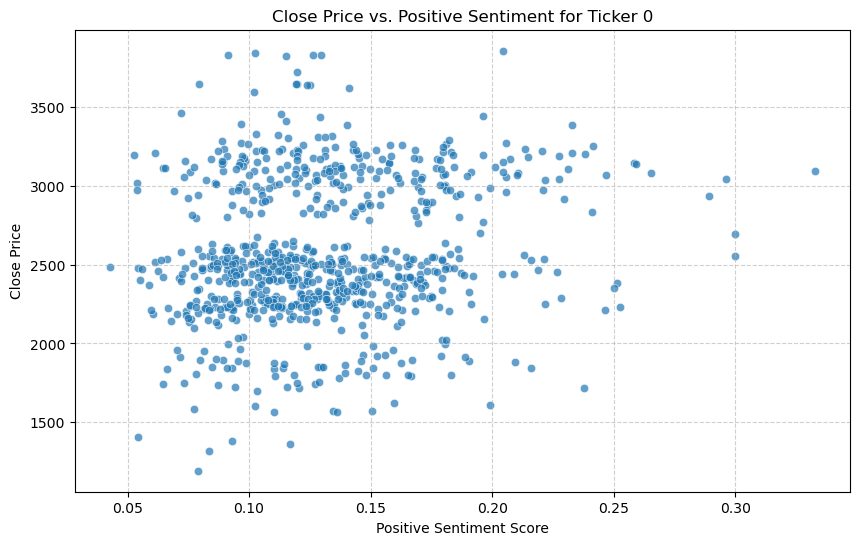

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter data for ticker_enumerated == 0
df_filtered = df[df['ticker_enumerated'] == 0]

# Create the scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='pos_score', y='Close', data=df_filtered, alpha=0.7)
plt.title('Close Price vs. Positive Sentiment for Ticker 0')
plt.xlabel('Positive Sentiment Score')
plt.ylabel('Close Price')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Feature Engineering: Creating Lagged Features and Target Variable

To predict the 11th day's closing price from 10 days of input, we need to create lagged features for each ticker. This involves shifting the data to create columns representing past values and a target column representing the future value we want to predict.

In [100]:
# Sort the DataFrame by Ticker and Date to ensure correct lagging
df = df.sort_values(by=['Ticker', 'Date'])

# Group by Ticker and create lagged features
features = ['Close', 'pos_score', 'neg_score', 'neu_score', 'Open', 'High', 'Low', 'Volume']

# Window sizes to tune: 7, 15, 30 days → max lags needed = 29
MAX_LAGS = 29

# Create lagged features for the past MAX_LAGS days
for feature in features:
    for i in range(1, MAX_LAGS + 1):
        df[f'{feature}_lag_{i}'] = df.groupby('Ticker')[feature].shift(i)

# Create the target variable: 'Close' price for the next day (shift -1)
df['target_close'] = df.groupby('Ticker')['Close'].shift(-1)

# Drop rows with NaN values resulting from lagging
df_prepared = df.dropna()

print("Lagged features and target variable created successfully.")
print(f"Created lags 1-{MAX_LAGS} for {len(features)} features = {MAX_LAGS * len(features)} lag columns")
print(df_prepared[['Ticker', 'Date', 'Close', 'pos_score', 'Close_lag_1', f'Close_lag_{MAX_LAGS}', 'target_close']].head())

/tmp/ipykernel_7050/2219431037.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{feature}_lag_{i}'] = df.groupby('Ticker')[feature].shift(i)


Lagged features and target variable created successfully.
Created lags 1-29 for 8 features = 232 lag columns
        Ticker        Date    Close  pos_score  Close_lag_1  Close_lag_29  \
1392  adanient  2023-02-13  1717.65   0.120746      1846.95       3841.20   
1440  adanient  2023-02-14  1749.70   0.073400      1717.65       3830.95   
1488  adanient  2023-02-15  1779.10   0.136880      1749.70       3827.05   
1536  adanient  2023-02-16  1796.60   0.166713      1779.10       3829.80   
1584  adanient  2023-02-17  1722.70   0.094083      1796.60       3824.25   

      target_close  
1392       1749.70  
1440       1779.10  
1488       1796.60  
1536       1722.70  
1584       1621.45  


/tmp/ipykernel_7050/2219431037.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['target_close'] = df.groupby('Ticker')['Close'].shift(-1)


In [101]:
print(df_prepared.columns.tolist())
print(df_prepared.shape)

['Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'date', 'cleaned_news', 'cleaned_news_len', 'neg_score', 'neu_score', 'pos_score', 'ticker_enumerated', 'ticker_scaled', 'Close_lag_1', 'Close_lag_2', 'Close_lag_3', 'Close_lag_4', 'Close_lag_5', 'Close_lag_6', 'Close_lag_7', 'Close_lag_8', 'Close_lag_9', 'Close_lag_10', 'Close_lag_11', 'Close_lag_12', 'Close_lag_13', 'Close_lag_14', 'Close_lag_15', 'Close_lag_16', 'Close_lag_17', 'Close_lag_18', 'Close_lag_19', 'Close_lag_20', 'Close_lag_21', 'Close_lag_22', 'Close_lag_23', 'Close_lag_24', 'Close_lag_25', 'Close_lag_26', 'Close_lag_27', 'Close_lag_28', 'Close_lag_29', 'pos_score_lag_1', 'pos_score_lag_2', 'pos_score_lag_3', 'pos_score_lag_4', 'pos_score_lag_5', 'pos_score_lag_6', 'pos_score_lag_7', 'pos_score_lag_8', 'pos_score_lag_9', 'pos_score_lag_10', 'pos_score_lag_11', 'pos_score_lag_12', 'pos_score_lag_13', 'pos_score_lag_14', 'pos_score_lag_15', 'pos_score_lag_16', 'pos_score_lag_17', 'pos_score_lag_18',

### Data Splitting (Train, Validation, Test)

Now we will split the data into training, validation, and test sets. Since this is time-series data, it's crucial to perform the split chronologically to avoid data leakage. We'll use an 80/10/10 ratio for train/validation/test.

In [102]:
import numpy as np

# Determine split points based on time
# First, convert 'Date' column to datetime objects if not already
df_prepared = df_prepared.copy() # Explicitly create a copy to avoid SettingWithCopyWarning
df_prepared['Date'] = pd.to_datetime(df_prepared['Date'])

# Get unique dates and sort them
dates = df_prepared['Date'].unique()
dates = np.sort(dates) # Fixed: Use np.sort for DatetimeArray

# Calculate split indices
total_samples = len(dates)
train_split_idx = int(total_samples * 0.8)
val_split_idx = int(total_samples * 0.9)

train_date_end = dates[train_split_idx - 1]
val_date_end = dates[val_split_idx - 1]

# Split the data chronologically
train_df = df_prepared[df_prepared['Date'] <= train_date_end]
val_df = df_prepared[(df_prepared['Date'] > train_date_end) & (df_prepared['Date'] <= val_date_end)]
test_df = df_prepared[df_prepared['Date'] > val_date_end]

print(f"Training data shape: {train_df.shape}")
print(f"Validation data shape: {val_df.shape}")
print(f"Test data shape: {test_df.shape}")

print("Data split into training, validation, and test sets successfully.")

Training data shape: (29221, 249)
Validation data shape: (3675, 249)
Test data shape: (3785, 249)
Data split into training, validation, and test sets successfully.


In [103]:
# Define the features (X) and target (y)
feature_cols = [
    'Open', 'High', 'Low', 'Close', 'Volume',
    'neg_score', 'neu_score', 'pos_score',
    'ticker_scaled'
]

# Add all lagged features (lag 1 to MAX_LAGS for each of the original features)
lag_features_base = ['Close', 'pos_score', 'neg_score', 'neu_score', 'Open', 'High', 'Low', 'Volume']
for base_feature in lag_features_base:
    for i in range(1, MAX_LAGS + 1):
        feature_cols.append(f'{base_feature}_lag_{i}')

target_col = 'target_close'

# Prepare X and y for train, validation, and test sets
X_train = train_df[feature_cols].copy()
y_train = train_df[target_col].copy()

X_val = val_df[feature_cols].copy()
y_val = val_df[target_col].copy()

X_test = test_df[feature_cols].copy()
y_test = test_df[target_col].copy()

print("Feature and target sets created successfully.")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

Feature and target sets created successfully.
X_train shape: (29221, 241), y_train shape: (29221,)
X_val shape: (3675, 241), y_val shape: (3675,)
X_test shape: (3785, 241), y_test shape: (3785,)


In [104]:
from sklearn.preprocessing import MinMaxScaler

# Dynamically generate columns to scale: price/volume features + all their lags
price_volume_features = ['Open', 'High', 'Low', 'Close', 'Volume']
columns_to_scale = list(price_volume_features)  # current-day values
for feat in price_volume_features:
    for i in range(1, MAX_LAGS + 1):
        columns_to_scale.append(f'{feat}_lag_{i}')

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Fit the scaler on the training data for the specified columns and transform
X_train[columns_to_scale] = scaler.fit_transform(X_train[columns_to_scale])

# Transform the validation and test data using the scaler fitted on the training data
X_val[columns_to_scale] = scaler.transform(X_val[columns_to_scale])
X_test[columns_to_scale] = scaler.transform(X_test[columns_to_scale])

print(f"Scaled {len(columns_to_scale)} columns (price/volume features + lags 1-{MAX_LAGS})")
print("X_train (first 5 rows after scaling):")
display(X_train[columns_to_scale[:10]].head())
print("X_test (first 5 rows after scaling):")
display(X_test[columns_to_scale[:10]].head())

Scaled 150 columns (price/volume features + lags 1-29)
X_train (first 5 rows after scaling):


,Open,High,Low,Close,Volume,Open_lag_1,Open_lag_2,Open_lag_3,Open_lag_4,Open_lag_5
1392,0.134889,0.137287,0.121981,0.124023,0.026116,0.128819,0.158722,0.136377,0.114125,0.114425
1440,0.126270,0.134888,0.118132,0.126407,0.031180,0.134889,0.128819,0.158722,0.136519,0.114125
1488,0.129643,0.130148,0.128616,0.128593,0.016332,0.126270,0.134889,0.128819,0.158861,0.136519
1536,0.132641,0.133857,0.131640,0.129895,0.011931,0.129643,0.126270,0.134889,0.128962,0.158861
1584,0.131142,0.129521,0.125077,0.124398,0.011533,0.132641,0.129643,0.126270,0.135032,0.128962


X_test (first 5 rows after scaling):


,Open,High,Low,Close,Volume,Open_lag_1,Open_lag_2,Open_lag_3,Open_lag_4,Open_lag_5
34334,0.168296,0.165506,0.167718,0.166932,0.001399,0.169234,0.169739,0.177991,0.182226,0.182540
34384,0.169458,0.175365,0.169367,0.175419,0.014748,0.168296,0.169234,0.169739,0.178127,0.182226
34434,0.178032,0.175899,0.177218,0.175685,0.005970,0.169458,0.168296,0.169234,0.169876,0.178127
34484,0.177887,0.177940,0.178163,0.177747,0.009919,0.178032,0.169458,0.168296,0.169371,0.169876
34534,0.180607,0.177876,0.179351,0.179383,0.005716,0.177887,0.178032,0.169458,0.168433,0.169371


### LSTM Model Training

To train an LSTM model, we first need to reshape our input data `X` into a 3D array: `(samples, timesteps, features_per_timestep)`.

We have identified 8 time-varying features (`Close`, `pos_window`, `neg_window`, `neu_window`, `Open`, `High`, `Low`, `Volume`) and an 11-day window (current day + 10 lags). Thus, `timesteps` will be 11 and `features_per_timestep` will be 8. The `ticker_scaled` feature will be excluded from the sequential input for this initial model setup.

In [105]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Define the base features that were lagged and will form our timesteps
features_base = ['Close', 'pos_score', 'neg_score', 'neu_score', 'Open', 'High', 'Low', 'Volume']
N_TIMESTEPS = 11  # Current day + 10 lagged days
N_FEATURES_PER_TIMESTEP = len(features_base)  # 8 features

# List to hold the reordered feature columns for LSTM input
lstm_feature_columns = []

# Add features from t-10 down to t-1 (lagged features)
for lag in range(10, 0, -1):
    for feature in features_base:
        lstm_feature_columns.append(f'{feature}_lag_{lag}')

# Add current day's features
for feature in features_base:
    lstm_feature_columns.append(feature)

# Select these specific columns from the X datasets and convert to numpy arrays
X_train_lstm = X_train[lstm_feature_columns].values
X_val_lstm   = X_val[lstm_feature_columns].values
X_test_lstm  = X_test[lstm_feature_columns].values

# Extract the 'ticker_scaled' feature separately
X_train_ticker = X_train['ticker_scaled'].values
X_val_ticker   = X_val['ticker_scaled'].values
X_test_ticker  = X_test['ticker_scaled'].values

# Reshape the data to (samples, timesteps, features_per_timestep)
X_train_reshaped = X_train_lstm.reshape((X_train_lstm.shape[0], N_TIMESTEPS, N_FEATURES_PER_TIMESTEP))
X_val_reshaped   = X_val_lstm.reshape((X_val_lstm.shape[0], N_TIMESTEPS, N_FEATURES_PER_TIMESTEP))
X_test_reshaped  = X_test_lstm.reshape((X_test_lstm.shape[0], N_TIMESTEPS, N_FEATURES_PER_TIMESTEP))

print("Data reshaped for LSTM model successfully.")
print(f"X_train_reshaped shape: {X_train_reshaped.shape}")
print(f"X_val_reshaped shape  : {X_val_reshaped.shape}")
print(f"X_test_reshaped shape : {X_test_reshaped.shape}")

Data reshaped for LSTM model successfully.
X_train_reshaped shape: (29221, 11, 8)
X_val_reshaped shape  : (3675, 11, 8)
X_test_reshaped shape : (3785, 11, 8)


### LSTM Model Definition

In [106]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Define the base features (including ticker_scaled as a static feature repeated across timesteps)
features_base = ['Close', 'pos_score', 'neg_score', 'neu_score', 'Open', 'High', 'Low', 'Volume', 'ticker_scaled']
N_TIMESTEPS = 11  # Current day + 10 lagged days
N_FEATURES_PER_TIMESTEP = len(features_base)  # 9 features

# List to hold the reordered feature columns for LSTM input
lstm_feature_columns = []

# Add features from t-10 down to t-1 (lagged features)
for lag in range(10, 0, -1):
    for feature in features_base:
        if feature == 'ticker_scaled':  # ticker_scaled has no lags; repeat the same column
            lstm_feature_columns.append(feature)
        else:
            lstm_feature_columns.append(f'{feature}_lag_{lag}')

# Add current day's features
for feature in features_base:
    lstm_feature_columns.append(feature)

# Select these specific columns from the X datasets and convert to numpy arrays
X_train_lstm = X_train[lstm_feature_columns].values
X_val_lstm   = X_val[lstm_feature_columns].values
X_test_lstm  = X_test[lstm_feature_columns].values

# Reshape the data to (samples, timesteps, features_per_timestep)
X_train_reshaped = X_train_lstm.reshape((X_train_lstm.shape[0], N_TIMESTEPS, N_FEATURES_PER_TIMESTEP))
X_val_reshaped   = X_val_lstm.reshape((X_val_lstm.shape[0], N_TIMESTEPS, N_FEATURES_PER_TIMESTEP))
X_test_reshaped  = X_test_lstm.reshape((X_test_lstm.shape[0], N_TIMESTEPS, N_FEATURES_PER_TIMESTEP))

print("Data reshaped for LSTM model successfully.")
print(f"X_train_reshaped shape: {X_train_reshaped.shape}")
print(f"X_val_reshaped shape  : {X_val_reshaped.shape}")
print(f"X_test_reshaped shape : {X_test_reshaped.shape}")

Data reshaped for LSTM model successfully.
X_train_reshaped shape: (29221, 11, 9)
X_val_reshaped shape  : (3675, 11, 9)
X_test_reshaped shape : (3785, 11, 9)


In [107]:
import os, random, sys

# ── Ensure conda CUDA libs are on LD_LIBRARY_PATH BEFORE importing TF ──
_conda_lib = os.path.join(sys.prefix, "lib")
_ld = os.environ.get("LD_LIBRARY_PATH", "")
if _conda_lib not in _ld:
    os.environ["LD_LIBRARY_PATH"] = f"{_conda_lib}:{_ld}"
    print(f"✓ Prepended {_conda_lib} to LD_LIBRARY_PATH")
else:
    print(f"✓ LD_LIBRARY_PATH already contains {_conda_lib}")

import numpy as np
import tensorflow as tf

# ── Reproducibility (must be set BEFORE building the model) ──
SEED = 32
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print(f"Random seeds set to {SEED}")

# ── GPU memory growth (prevents TF from grabbing all 4 GB at once) ──
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"✓ {len(gpus)} GPU(s) detected: {[g.name for g in gpus]}")
    print(f"  TF version : {tf.__version__}")

    # Mixed precision: FP16 compute on Tensor Cores → ~2× throughput on RTX 3050
    tf.keras.mixed_precision.set_global_policy('mixed_float16')
    print("✓ Mixed precision policy: mixed_float16")
    BATCH_SIZE = 512   # large batch saturates GPU CUDA cores
else:
    print("⚠ No GPU found — running on CPU")
    BATCH_SIZE = 64

print(f"Batch size : {BATCH_SIZE}")

✓ LD_LIBRARY_PATH already contains /home/mveen/miniconda3/envs/ml/lib
Random seeds set to 32
✓ 1 GPU(s) detected: ['/physical_device:GPU:0']
  TF version : 2.21.0
✓ Mixed precision policy: mixed_float16
Batch size : 512


## Per-Window Hyperparameter Tuning (Bayesian Optimization)

For **each** window size (7, 15, 30 days), we run a full **Bayesian Optimization** search over:

| HP | Range |
|---|---|
| `lstm_units_1` | 64 / 128 / 256 |
| `lstm_units_2` | 32 / 64 / 128 |
| `dropout_rate` | 0.1 → 0.5 |
| `dense_units` | 16 / 32 / 64 |
| `learning_rate` | 1e-4 → 1e-2 (log scale) |

This finds the **best architecture for each lookback length**, then we compare the 3 winners to pick the overall best (window + HP).

In [108]:

import os, gc, time
import keras_tuner as kt
from tensorflow import keras
from tensorflow.keras import layers

# ══════════════════════════════════════════════════════════════════════
#  GPU sanity check — run once before the loop
# ══════════════════════════════════════════════════════════════════════
gpus = tf.config.list_physical_devices('GPU')
print(f"GPU devices visible to TF: {gpus}")
print(f"Mixed precision policy   : {tf.keras.mixed_precision.global_policy().name}")
assert len(gpus) > 0, "❌ No GPU detected — training will be slow!"
assert tf.keras.mixed_precision.global_policy().name == 'mixed_float16', \
    "❌ mixed_float16 not active — re-run the GPU setup cell above"
print("✓ GPU + mixed_float16 confirmed\n")

# ══════════════════════════════════════════════════════════════════════
#  Configuration
# ══════════════════════════════════════════════════════════════════════
WINDOW_SIZES    = [7, 15, 30]
SEARCH_EPOCHS   = 30        # max epochs per trial during search (EarlyStopping cuts short)
FINAL_EPOCHS    = 180       # full training for the best HP of each window
MAX_TRIALS      = 20        # Bayesian trials per window
AUTOTUNE        = tf.data.AUTOTUNE

features_base_lstm = ['Close', 'pos_score', 'neg_score', 'neu_score',
                      'Open', 'High', 'Low', 'Volume', 'ticker_scaled']
N_FEAT = len(features_base_lstm)  # 9

print(f"Window sizes : {WINDOW_SIZES}")
print(f"Search trials: {MAX_TRIALS} per window  |  Search epochs: {SEARCH_EPOCHS}")
print(f"Final epochs : {FINAL_EPOCHS}")


# ══════════════════════════════════════════════════════════════════════
#  Helper: reshape data for a given window size
# ══════════════════════════════════════════════════════════════════════
def reshape_for_window(ws, X_src):
    """Build column list for `ws` days and reshape to 3-D."""
    n_lags = ws - 1
    cols = []
    for lag in range(n_lags, 0, -1):
        for feat in features_base_lstm:
            cols.append('ticker_scaled' if feat == 'ticker_scaled'
                        else f'{feat}_lag_{lag}')
    for feat in features_base_lstm:
        cols.append(feat)
    return X_src[cols].values.reshape(-1, ws, N_FEAT)


# ══════════════════════════════════════════════════════════════════════
#  Model builder factory (closure over ws so Keras Tuner gets shape)
# ══════════════════════════════════════════════════════════════════════
def make_build_fn(ws):
    def build_model(hp):
        lstm_1  = hp.Choice('lstm_units_1', values=[64, 128, 256])
        lstm_2  = hp.Choice('lstm_units_2', values=[32, 64, 128])
        drop    = hp.Float ('dropout_rate', min_value=0.1, max_value=0.5, step=0.1)
        dense   = hp.Choice('dense_units',  values=[16, 32, 64])
        lr      = hp.Float ('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')

        inp = layers.Input(shape=(ws, N_FEAT), name='lstm_input')
        x   = layers.LSTM(lstm_1, return_sequences=True, name='lstm_1')(inp)
        x   = layers.Dropout(drop)(x)
        x   = layers.LSTM(lstm_2, name='lstm_2')(x)
        x   = layers.Dropout(drop)(x)
        x   = layers.Dense(dense, activation='relu')(x)
        out = layers.Dense(1, dtype='float32', name='output')(x)

        mdl = keras.Model(inp, out)
        mdl.compile(
            optimizer=keras.optimizers.Adam(learning_rate=lr),
            loss='mse',
            metrics=['mae', 'root_mean_squared_error'],
        )
        return mdl
    return build_model


# ══════════════════════════════════════════════════════════════════════
#  Check for saved models — skip training if all checkpoints exist
# ══════════════════════════════════════════════════════════════════════
SKIP_TRAINING = all(
    os.path.exists(f'checkpoints/best_lstm_w{ws}.keras') for ws in WINDOW_SIZES
)

results = {}

if SKIP_TRAINING:
    # ── Load saved models instead of retraining ──
    print("=" * 70)
    print("  ✓ SAVED MODELS FOUND — SKIPPING TRAINING (loading from disk)")
    print("=" * 70)

    for ws in WINDOW_SIZES:
        path = f'checkpoints/best_lstm_w{ws}.keras'
        mdl = keras.models.load_model(path)
        X_te = reshape_for_window(ws, X_test)

        # Evaluate loaded model on test set
        loss, mae, rmse, mape = mdl.evaluate(X_te, y_test, verbose=0)

        results[ws] = {
            'model':       mdl,
            'history':     None,          # not available when loaded from disk
            'hp':          {},            # not available
            'trials':      [],            # not available
            'val_loss':    loss,           # use test MSE as proxy
            'test_mse':    loss,
            'test_mae':    mae,
            'test_rmse':   rmse,
            'test_mape':   mape,
            'X_test':      X_te,
            'epochs_run':  0,
            'time_min':    0,
            'loaded_from_disk': True,
        }
        print(f"  ✓ {path} → test MSE={loss:.2f}, MAE={mae:.2f}, RMSE={rmse:.2f}, MAPE={mape:.2f}%")

    print(f"\n{'#'*70}")
    print("#  ALL MODELS LOADED FROM DISK (training skipped)")
    print(f"{'#'*70}")

    # Save the overall best model as well
    best_ws_loaded = min(results, key=lambda w: results[w]['test_mse'])
    model = results[best_ws_loaded]['model']
    model.save('lstm_stock_predictor_norm_2lstm_tsip.keras')
    print(f"\n★ Best window = {best_ws_loaded}d  (lowest test MSE)")

else:
    # ══════════════════════════════════════════════════════════════════
    #  Main loop: for each window → HP search → full train with best HP
    # ══════════════════════════════════════════════════════════════════

    for ws in WINDOW_SIZES:
        t0 = time.time()
        print(f"\n{'#'*70}")
        print(f"#  WINDOW SIZE = {ws} days  ({ws-1} lags + current day)")
        print(f"{'#'*70}")

        # ── Verify GPU is still active (no clear_session to break it) ──
        print(f"  GPU check: {tf.config.list_physical_devices('GPU')}")
        print(f"  Policy   : {tf.keras.mixed_precision.global_policy().name}")

        # ── Reshape ──
        X_tr = reshape_for_window(ws, X_train)
        X_v  = reshape_for_window(ws, X_val)
        X_te = reshape_for_window(ws, X_test)
        print(f"  Shapes → train {X_tr.shape}, val {X_v.shape}, test {X_te.shape}")

        # ── tf.data pipelines (GPU receives data via prefetch) ──
        tr_ds = (tf.data.Dataset
                 .from_tensor_slices((X_tr, y_train.values.astype('float32')))
                 .shuffle(len(X_tr), seed=SEED).batch(BATCH_SIZE).prefetch(AUTOTUNE))
        vl_ds = (tf.data.Dataset
                 .from_tensor_slices((X_v, y_val.values.astype('float32')))
                 .batch(BATCH_SIZE).prefetch(AUTOTUNE))

        # ── Bayesian Optimization tuner ──
        tuner = kt.BayesianOptimization(
            hypermodel       = make_build_fn(ws),
            objective        = kt.Objective('val_loss', direction='min'),
            max_trials       = MAX_TRIALS,
            num_initial_points = 5,
            seed             = SEED,
            directory        = 'kt_tuning',
            project_name     = f'lstm_w{ws}',
            overwrite        = True,
        )

        search_cbs = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss', patience=5, restore_best_weights=True),
        ]

        print(f"\n  ▸ Starting Bayesian search ({MAX_TRIALS} trials, {SEARCH_EPOCHS} epochs max) …")
        tuner.search(tr_ds, epochs=SEARCH_EPOCHS, validation_data=vl_ds,
                     callbacks=search_cbs, verbose=1)

        best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
        hp_dict = best_hp.values.copy()
        print(f"\n  ✓ Best HP for {ws}-day window:")
        for k, v in hp_dict.items():
            print(f"      {k:20s} = {v}")

        # ── Collect all trial scores for this window ──
        trial_rows = []
        for trial in tuner.oracle.trials.values():
            if trial.score is not None:
                row = dict(trial.hyperparameters.values)
                row['val_loss'] = trial.score
                row['trial_id'] = trial.trial_id
                trial_rows.append(row)

        # ── Full training with best HP ──
        print(f"\n  ▸ Full training ({FINAL_EPOCHS} epochs) with best HP …")
        mdl = tuner.hypermodel.build(best_hp)
        mdl.compile(
            optimizer=keras.optimizers.Adam(learning_rate=hp_dict['learning_rate']),
            loss='mse',
            metrics=['mae', 'root_mean_squared_error', 'mean_absolute_percentage_error'],
        )

        os.makedirs('checkpoints', exist_ok=True)
        train_cbs = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
            tf.keras.callbacks.ReduceLROnPlateau(
                monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1),
            tf.keras.callbacks.ModelCheckpoint(
                filepath=f'checkpoints/best_lstm_w{ws}.keras',
                monitor='val_loss', save_best_only=True, verbose=0),
        ]

        hist = mdl.fit(tr_ds, epochs=FINAL_EPOCHS, validation_data=vl_ds,
                       callbacks=train_cbs, verbose=1)

        # ── Evaluate ──
        loss, mae, rmse, mape = mdl.evaluate(X_te, y_test, verbose=0)
        best_vloss = min(hist.history['val_loss'])

        elapsed = time.time() - t0
        results[ws] = {
            'model':       mdl,
            'history':     hist,
            'hp':          hp_dict,
            'trials':      trial_rows,
            'val_loss':    best_vloss,
            'test_mse':    loss,
            'test_mae':    mae,
            'test_rmse':   rmse,
            'test_mape':   mape,
            'X_test':      X_te,
            'epochs_run':  len(hist.history['loss']),
            'time_min':    elapsed / 60,
            'loaded_from_disk': False,
        }

        print(f"\n  ★ Window {ws}d final → val_loss={best_vloss:.2f}  |  "
              f"test MSE={loss:.2f}, MAE={mae:.2f}, RMSE={rmse:.2f}, MAPE={mape:.2f}%")
        print(f"  ⏱ Time: {elapsed/60:.1f} min")

        # ── Free unused tensors but do NOT call clear_session ──
        del tuner, tr_ds, vl_ds, X_tr, X_v
        gc.collect()

    print(f"\n{'#'*70}")
    print("#  ALL WINDOWS COMPLETE")
    print(f"{'#'*70}")
    total_time = sum(r['time_min'] for r in results.values())
    print(f"  Total time: {total_time:.1f} min")

    # Save the overall best model
    best_ws_trained = min(results, key=lambda w: results[w]['val_loss'])
    results[best_ws_trained]['model'].save('lstm_stock_predictor_norm_2lstm_tsip.keras')
    print(f"✓ Saved best model ({best_ws_trained}d) as 'lstm_stock_predictor_norm_2lstm_tsip.keras'")


GPU devices visible to TF: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision policy   : mixed_float16
✓ GPU + mixed_float16 confirmed

Window sizes : [7, 15, 30]
Search trials: 20 per window  |  Search epochs: 30
Final epochs : 180
  ✓ SAVED MODELS FOUND — SKIPPING TRAINING (loading from disk)


/home/mveen/miniconda3/envs/ml/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 26 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/home/mveen/miniconda3/envs/ml/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 22 variables whereas the saved optimizer has 0 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


  ✓ checkpoints/best_lstm_w7.keras → test MSE=232491.39, MAE=126.64, RMSE=482.17, MAPE=4.21%


/home/mveen/miniconda3/envs/ml/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 26 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/home/mveen/miniconda3/envs/ml/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 22 variables whereas the saved optimizer has 0 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


  ✓ checkpoints/best_lstm_w15.keras → test MSE=9636259.00, MAE=1825.83, RMSE=3104.23, MAPE=177.50%


/home/mveen/miniconda3/envs/ml/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 26 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/home/mveen/miniconda3/envs/ml/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 22 variables whereas the saved optimizer has 0 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


  ✓ checkpoints/best_lstm_w30.keras → test MSE=279816.59, MAE=153.45, RMSE=528.98, MAPE=6.24%

######################################################################
#  ALL MODELS LOADED FROM DISK (training skipped)
######################################################################

★ Best window = 7d  (lowest test MSE)


In [109]:

import pandas as pd

# ══════════════════════════════════════════════════════════════════════
#  Per-window best HP + comparison table
# ══════════════════════════════════════════════════════════════════════

loaded_from_disk = results.get(WINDOW_SIZES[0], {}).get('loaded_from_disk', False)

# ── Print best HP for each window (only if trained, not loaded) ──
if not loaded_from_disk:
    for ws in WINDOW_SIZES:
        r = results[ws]
        print(f"\n{'─'*60}")
        print(f"  Best HP for {ws}-day window  (val_loss = {r['val_loss']:.2f})")
        print(f"{'─'*60}")
        for k, v in r['hp'].items():
            print(f"    {k:20s} = {v}")

# ── Summary table ──
rows = []
for ws, r in results.items():
    row = {'Window (days)': ws}
    if not loaded_from_disk:
        row['Epochs Run'] = r['epochs_run']
        row.update({k: (round(v, 6) if isinstance(v, float) else v) for k, v in r['hp'].items()})
    row['Best val_loss'] = round(r['val_loss'], 2)
    row['Test MSE']      = round(r['test_mse'], 2)
    row['Test MAE']      = round(r['test_mae'], 2)
    row['Test RMSE']     = round(r['test_rmse'], 2)
    row['Test MAPE (%)'] = round(r['test_mape'], 2)
    if loaded_from_disk:
        row['Source'] = 'Loaded from disk'
    rows.append(row)

results_df = pd.DataFrame(rows).sort_values('Best val_loss').reset_index(drop=True)

print(f"\n{'═'*70}")
print("  OVERALL COMPARISON  (ranked by val_loss)")
print(f"{'═'*70}")
display(results_df)

# ── Identify overall best ──
best_ws = int(results_df.iloc[0]['Window (days)'])
r = results[best_ws]

print(f"\n★★★  OVERALL BEST: {best_ws}-day window  ★★★")
print(f"  val_loss      = {r['val_loss']:.4f}")
print(f"  Test MSE      = {r['test_mse']:.4f}")
print(f"  Test MAE      = {r['test_mae']:.4f}")
print(f"  Test RMSE     = {r['test_rmse']:.4f}")
print(f"  Test MAPE     = {r['test_mape']:.4f}%")
if not loaded_from_disk:
    print(f"  Epochs run    = {r['epochs_run']}")
    print(f"  Hyperparameters:")
    for k, v in r['hp'].items():
        print(f"    {k:20s} = {v}")

# ── Set best model and test data for downstream evaluation cells ──
model           = results[best_ws]['model']
X_test_reshaped = results[best_ws]['X_test']
N_TIMESTEPS     = best_ws
N_FEATURES_PER_TIMESTEP = N_FEAT

print(f"\n→ `model` and `X_test_reshaped` set to {best_ws}-day window for cells below.")



══════════════════════════════════════════════════════════════════════
  OVERALL COMPARISON  (ranked by val_loss)
══════════════════════════════════════════════════════════════════════


,Window (days),Best val_loss,Test MSE,Test MAE,Test RMSE,Test MAPE (%),Source
0,7,232491.39,232491.39,126.64,482.17,4.21,Loaded from disk
1,30,279816.59,279816.59,153.45,528.98,6.24,Loaded from disk
2,15,9636259.00,9636259.00,1825.83,3104.23,177.50,Loaded from disk



★★★  OVERALL BEST: 7-day window  ★★★
  val_loss      = 232491.3906
  Test MSE      = 232491.3906
  Test MAE      = 126.6424
  Test RMSE     = 482.1736
  Test MAPE     = 4.2120%

→ `model` and `X_test_reshaped` set to 7-day window for cells below.


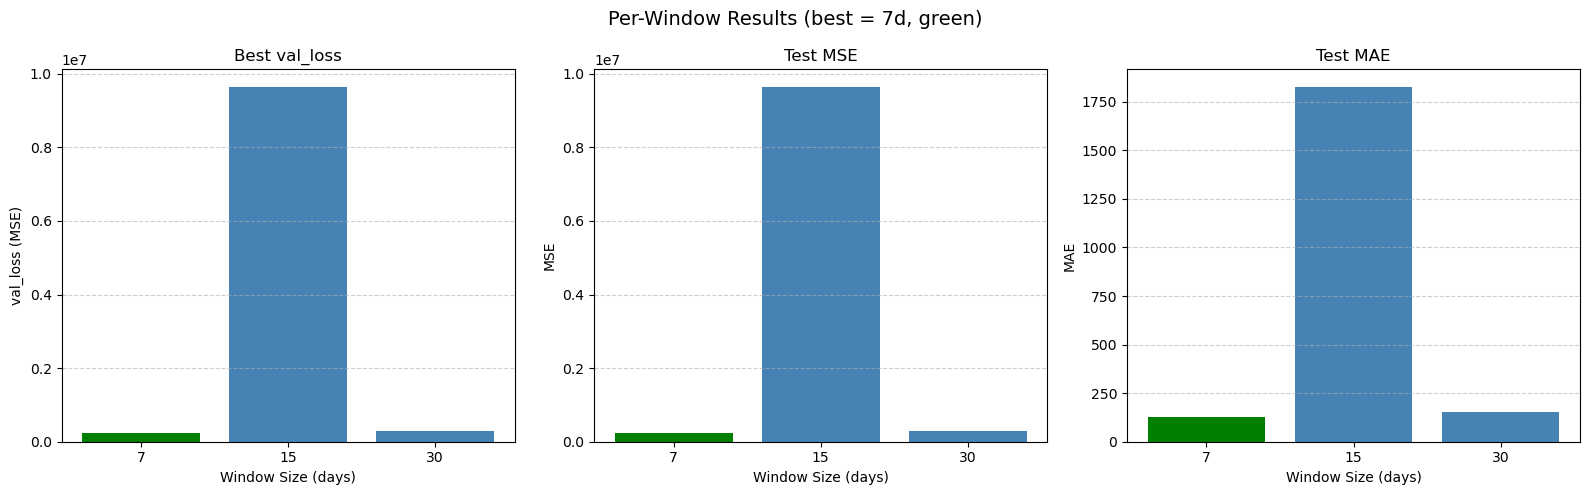

ℹ Validation loss curves not available (models loaded from disk)
ℹ Trial-level plots not available (models loaded from disk)


In [110]:

import matplotlib.pyplot as plt

loaded_from_disk = results.get(WINDOW_SIZES[0], {}).get('loaded_from_disk', False)

# ══════════════════════════════════════════════════════════════════════
#  1. Bar charts: val_loss / test MSE / test MAE per window
# ══════════════════════════════════════════════════════════════════════
windows    = list(WINDOW_SIZES)
val_losses = [results[ws]['val_loss'] for ws in windows]
test_mses  = [results[ws]['test_mse'] for ws in windows]
test_maes  = [results[ws]['test_mae'] for ws in windows]
colors     = ['green' if ws == best_ws else 'steelblue' for ws in windows]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, data, title, ylabel in zip(
    axes,
    [val_losses, test_mses, test_maes],
    ['Best val_loss', 'Test MSE', 'Test MAE'],
    ['val_loss (MSE)', 'MSE', 'MAE'],
):
    ax.bar([str(w) for w in windows], data, color=colors)
    ax.set_title(title)
    ax.set_xlabel('Window Size (days)')
    ax.set_ylabel(ylabel)
    ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.suptitle(f'Per-Window Results (best = {best_ws}d, green)', fontsize=14)
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════
#  2. Validation loss curves (only if trained, not loaded from disk)
# ══════════════════════════════════════════════════════════════════════
if not loaded_from_disk:
    fig, ax = plt.subplots(figsize=(14, 5))
    for ws in WINDOW_SIZES:
        ax.plot(results[ws]['history'].history['val_loss'], label=f'{ws}-day window')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('val_loss (MSE)')
    ax.set_title('Full-Training Validation Loss — All Window Sizes')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print("ℹ Validation loss curves not available (models loaded from disk)")

# ══════════════════════════════════════════════════════════════════════
#  3. Trial-level scatter per window (only if trained)
# ══════════════════════════════════════════════════════════════════════
if not loaded_from_disk:
    fig, axes = plt.subplots(1, len(WINDOW_SIZES), figsize=(6 * len(WINDOW_SIZES), 5), sharey=True)
    for ax, ws in zip(axes, WINDOW_SIZES):
        trials = pd.DataFrame(results[ws]['trials']).sort_values('val_loss')
        ax.barh(range(len(trials)), trials['val_loss'],
                color=['green' if i == 0 else 'steelblue' for i in range(len(trials))])
        ax.set_title(f'{ws}-day window ({len(trials)} trials)')
        ax.set_xlabel('val_loss (MSE)')
        ax.set_ylabel('Trial rank')
        ax.grid(axis='x', linestyle='--', alpha=0.6)
    plt.suptitle('Bayesian Search Trials per Window', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("ℹ Trial-level plots not available (models loaded from disk)")


In [111]:

# ── Window tuning visualization is in the cell above ──
# ── This cell previously held Keras Tuner trial visualization ──
print(f"Best model: {best_ws}-day window")
model.summary()


Best model: 7-day window


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_input (InputLayer)         │ (None, 7, 9)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 7, 64)          │        18,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 7, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │         2,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 359,529 (1.37 MB)

 Trainable params: 119,841 (468.13 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 239,688 (936.29 KB)

In [112]:

# ── Model is already built and trained from window size tuning above ──
print(f"Model assigned from {best_ws}-day window tuning")
print(f"Model input shape : {model.input_shape}")
print(f"Model output shape: {model.output_shape}")


Model assigned from 7-day window tuning
Model input shape : (None, 7, 9)
Model output shape: (None, 1)


### Compile the LSTM Model

In [113]:

# Seeds were already set in the GPU/TF setup cell above (SEED=32).
# This cell is kept as a checkpoint to verify variables are still in scope.
print(f"SEED={SEED}, BATCH_SIZE={BATCH_SIZE}")
print(f"Training samples : {X_train_reshaped.shape[0]:,}")
print(f"Validation samples: {X_val_reshaped.shape[0]:,}")
print(f"Test samples     : {X_test_reshaped.shape[0]:,}")


SEED=32, BATCH_SIZE=512
Training samples : 29,221
Validation samples: 3,675
Test samples     : 3,785


In [114]:

# ── Model is already compiled in the window tuning loop ──
print(f"Model already compiled with best HP from {best_ws}-day window")


Model already compiled with best HP from 7-day window


In [115]:

# ── Training / loading status ──
loaded_from_disk = results.get(WINDOW_SIZES[0], {}).get('loaded_from_disk', False)
if loaded_from_disk:
    print(f"Models loaded from disk — best window = {best_ws} days")
    print(f"  Test MSE     : {results[best_ws]['test_mse']:.4f}")
    print(f"  Test MAE     : {results[best_ws]['test_mae']:.4f}")
    print("Proceed to evaluation cells below.")
else:
    print(f"Training already complete — best window = {best_ws} days")
    print(f"  Epochs run   : {results[best_ws]['epochs_run']}")
    print(f"  Best val_loss: {results[best_ws]['val_loss']:.4f}")
    print("Proceed to evaluation cells below.")


Models loaded from disk — best window = 7 days
  Test MSE     : 232491.3906
  Test MAE     : 126.6424
Proceed to evaluation cells below.


In [116]:

# ══════════════════════════════════════════════════════════════════════
#  Fallback: Load saved model (only if not already set by cell above)
# ══════════════════════════════════════════════════════════════════════
from tensorflow import keras

if 'model' not in dir() or model is None:
    best_ws = 7
    N_FEAT  = 9

    features_base_lstm = ['Close', 'pos_score', 'neg_score', 'neu_score',
                          'Open', 'High', 'Low', 'Volume', 'ticker_scaled']

    def reshape_for_window(ws, X_src):
        n_lags = ws - 1
        cols = []
        for lag in range(n_lags, 0, -1):
            for feat in features_base_lstm:
                cols.append('ticker_scaled' if feat == 'ticker_scaled'
                            else f'{feat}_lag_{lag}')
        for feat in features_base_lstm:
            cols.append(feat)
        return X_src[cols].values.reshape(-1, ws, N_FEAT)

    model = keras.models.load_model('lstm_stock_predictor_norm_2lstm_tsip.keras')
    X_test_reshaped = reshape_for_window(best_ws, X_test)
    print(f"✓ Loaded model from disk: input_shape={model.input_shape}")
    print(f"✓ X_test_reshaped shape: {X_test_reshaped.shape}")
else:
    print(f"✓ Model already loaded (input_shape={model.input_shape}) — skipping reload")
    print(f"✓ X_test_reshaped shape: {X_test_reshaped.shape}")


✓ Model already loaded (input_shape=(None, 7, 9)) — skipping reload
✓ X_test_reshaped shape: (3785, 7, 9)


In [117]:
import os, json, glob
import pandas as pd

# ══════════════════════════════════════════════════════════════════════
#  Best Hyperparameters for Each Window Size
# ══════════════════════════════════════════════════════════════════════

hp_rows = []

for ws in WINDOW_SIZES:
    print(f"\n{'═'*60}")
    print(f"  Window Size = {ws} days")
    print(f"{'═'*60}")

    # ── Try 1: from in-memory results (if trained this session) ──
    r = results.get(ws, {})
    if r.get('hp'):
        print("  (source: current training session)")
        for k, v in r['hp'].items():
            print(f"    {k:20s} = {v}")
        hp_row = {'Window (days)': ws, **r['hp']}
        hp_rows.append(hp_row)

    else:
        # ── Try 2: reload from Keras Tuner saved trials on disk ──
        tuner_dir = f'kt_tuning/lstm_w{ws}'
        trial_dirs = sorted(glob.glob(os.path.join(tuner_dir, 'trial_*')))

        if trial_dirs:
            print(f"  (source: Keras Tuner saved trials — {tuner_dir}/)")
            best_score = float('inf')
            best_hp = {}

            for td in trial_dirs:
                trial_json = os.path.join(td, 'trial.json')
                if os.path.exists(trial_json):
                    with open(trial_json) as f:
                        trial_data = json.load(f)
                    score = trial_data.get('score')
                    if score is not None and score < best_score:
                        best_score = score
                        best_hp = trial_data.get('hyperparameters', {}).get('values', {})

            if best_hp:
                for k, v in best_hp.items():
                    print(f"    {k:20s} = {v}")
                print(f"    {'val_loss':20s} = {best_score:.4f}")
                hp_row = {'Window (days)': ws, **best_hp, 'val_loss': round(best_score, 4)}
                hp_rows.append(hp_row)
            else:
                print("    ⚠ No valid trials found on disk")
        else:
            # ── Try 3: extract architecture from loaded model ──
            mdl = r.get('model')
            if mdl:
                print("  (source: loaded model architecture)")
                for layer in mdl.layers:
                    cfg = layer.get_config()
                    if 'lstm' in layer.name:
                        print(f"    {layer.name:20s} → units = {cfg.get('units')}")
                    elif 'dropout' in layer.name:
                        print(f"    {layer.name:20s} → rate  = {cfg.get('rate')}")
                    elif 'dense' in layer.name and layer.name != 'output':
                        print(f"    {layer.name:20s} → units = {cfg.get('units')}")
            else:
                print("    ⚠ No HP info available (no tuner data or model)")

# ── Summary table ──
if hp_rows:
    print(f"\n{'═'*60}")
    print("  Summary: Best Hyperparameters per Window")
    print(f"{'═'*60}")
    hp_df = pd.DataFrame(hp_rows)
    display(hp_df)



════════════════════════════════════════════════════════════
  Window Size = 7 days
════════════════════════════════════════════════════════════
  (source: Keras Tuner saved trials — kt_tuning/lstm_w7/)
    lstm_units_1         = 64
    lstm_units_2         = 64
    dropout_rate         = 0.30000000000000004
    dense_units          = 32
    learning_rate        = 0.0004543609940965399
    val_loss             = 9921220.0000

════════════════════════════════════════════════════════════
  Window Size = 15 days
════════════════════════════════════════════════════════════
  (source: Keras Tuner saved trials — kt_tuning/lstm_w15/)
    lstm_units_1         = 256
    lstm_units_2         = 64
    dropout_rate         = 0.5
    dense_units          = 16
    learning_rate        = 0.008547485565344062
    val_loss             = 287236.1875

════════════════════════════════════════════════════════════
  Window Size = 30 days
════════════════════════════════════════════════════════════
  (sourc

,Window (days),lstm_units_1,lstm_units_2,dropout_rate,dense_units,learning_rate,val_loss
0,7,64,64,0.3,32,0.000454,9.921220e+06
1,15,256,64,0.5,16,0.008547,2.872362e+05
2,30,64,32,0.4,16,0.009978,2.274752e+05


In [118]:
# Evaluate the model on the test set
loss, mae, rmse, mape = model.evaluate(X_test_reshaped, y_test, verbose=0)

print(f"Test Loss (MSE): {loss}")
print(f"Test MAE: {mae}")
print(f"Test RMSE: {rmse}")
print(f"Test MAPE: {mape}")

Test Loss (MSE): 232491.390625
Test MAE: 126.64239501953125
Test RMSE: 482.1736145019531
Test MAPE: 4.212008953094482


In [119]:
# Make predictions on the test set
predictions = model.predict(X_test_reshaped)

# Reshape y_test for plotting if it's a Series
y_test_np = y_test.values.reshape(-1, 1)

print("Predictions made successfully.")
print(f"Predictions shape: {predictions.shape}")
print(f"Actual values shape: {y_test_np.shape}")

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Predictions made successfully.
Predictions shape: (3785, 1)
Actual values shape: (3785, 1)


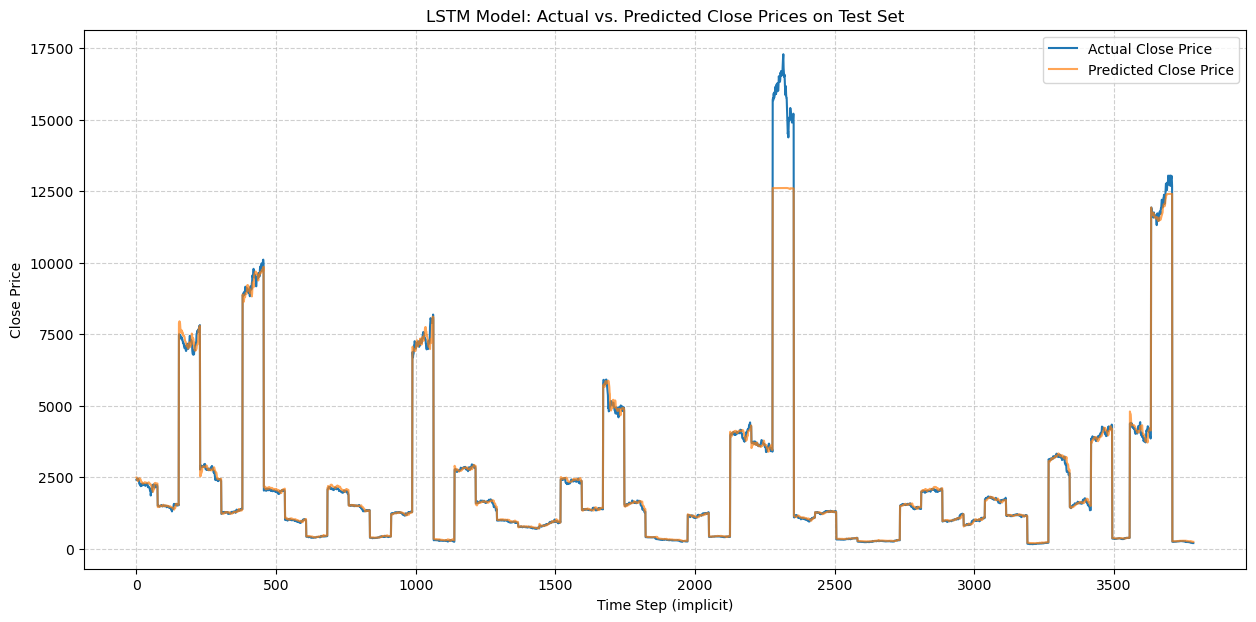

In [120]:
import matplotlib.pyplot as plt

# Create a DataFrame for easier plotting
plot_df = pd.DataFrame({
    'Actual Close': y_test_np.flatten(),
    'Predicted Close': predictions.flatten()
})

plt.figure(figsize=(15, 7))
plt.plot(plot_df['Actual Close'], label='Actual Close Price')
plt.plot(plot_df['Predicted Close'], label='Predicted Close Price', alpha=0.7)
plt.title('LSTM Model: Actual vs. Predicted Close Prices on Test Set')
plt.xlabel('Time Step (implicit)')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [121]:
display(plot_df.head(10))

,Actual Close,Predicted Close
0,2408.69,2492.984619
1,2412.27,2463.645996
2,2440.00,2446.520996
3,2462.00,2401.058594
4,2436.80,2387.971191
5,2433.10,2367.375977
6,2446.10,2373.532715
7,2422.30,2416.262695
8,2399.20,2439.082031
9,2332.90,2449.260254


In [122]:
model.save('lstm_stock_predictor_norm_2lstm_tsip.keras')
print("Trained model saved as 'lstm_stock_predictor.keras'")

Trained model saved as 'lstm_stock_predictor.keras'


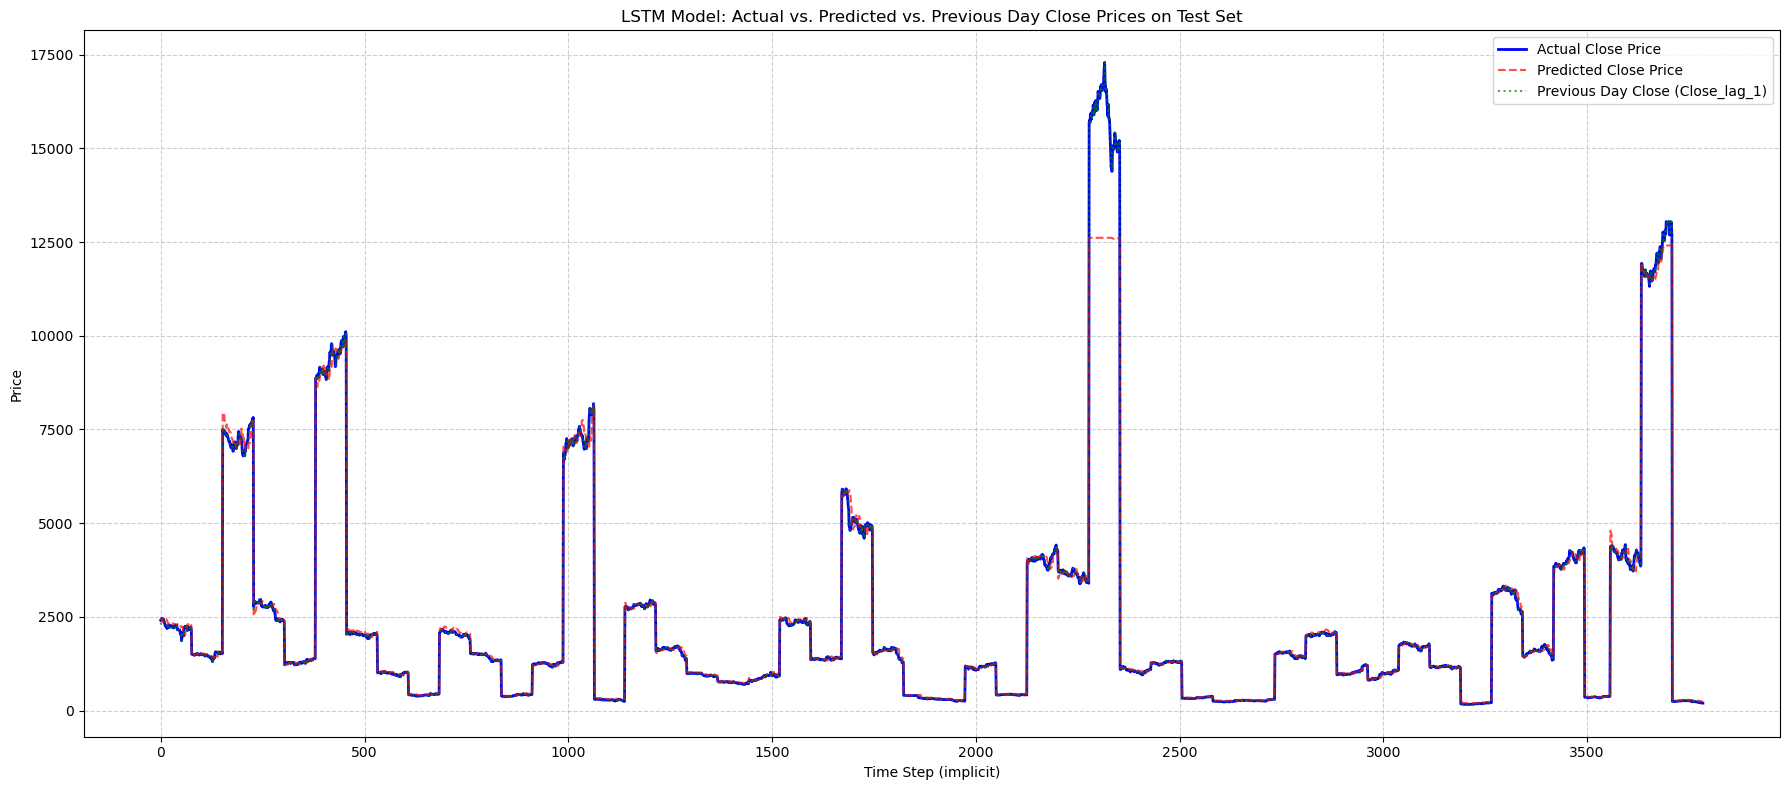

,Actual Close,Predicted Close,Close_lag_1
0,2408.69,2492.984619,2294.58
1,2412.27,2463.645996,2408.69
2,2440.00,2446.520996,2412.27
3,2462.00,2401.058594,2440.00
4,2436.80,2387.971191,2462.00


In [123]:
import matplotlib.pyplot as plt
import pandas as pd

# To inverse transform 'Close_lag_1', we need the full 'columns_to_scale' context from X_test
# First, ensure X_test is a DataFrame (it already is)

# Create a temporary DataFrame with all scaled columns that were used for fitting the scaler
temp_X_test_scaled_for_inverse = X_test[columns_to_scale]

# Inverse transform these columns. This will return a numpy array in the original scale.
original_scale_features = scaler.inverse_transform(temp_X_test_scaled_for_inverse)

# Convert back to DataFrame to easily select the 'Close_lag_1' column, preserving index for potential merges
original_scale_features_df = pd.DataFrame(original_scale_features, columns=columns_to_scale, index=X_test.index)

# Now, extract the inverse-transformed 'Close_lag_1'
inverse_transformed_close_lag_1 = original_scale_features_df['Close'].values.flatten()

# Combine the relevant data into a single DataFrame for plotting
combined_plot_df = pd.DataFrame({
    'Actual Close': y_test_np.flatten(),
    'Predicted Close': predictions.flatten(),
    'Close_lag_1': inverse_transformed_close_lag_1
})

plt.figure(figsize=(18, 8))
plt.plot(combined_plot_df['Actual Close'], label='Actual Close Price', color='blue', linewidth=2)
plt.plot(combined_plot_df['Predicted Close'], label='Predicted Close Price', color='red', linestyle='--', alpha=0.7)
plt.plot(combined_plot_df['Close_lag_1'], label='Previous Day Close (Close_lag_1)', color='green', linestyle=':', alpha=0.7)
plt.title('LSTM Model: Actual vs. Predicted vs. Previous Day Close Prices on Test Set')
plt.xlabel('Time Step (implicit)')
plt.ylabel('Price')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

display(combined_plot_df.head())

MAPE for ALL tickers (sorted best → worst):


,Ticker,MAPE (%)
0,nestleind,1.471584
1,grasim,1.536167
2,tataconsum,1.744947
3,bajaj-auto,1.817876
4,ultracemco,2.032941
5,cipla,2.055751
6,axisbank,2.082114
7,drreddy,2.259352
8,icicibank,2.330121
9,m&m,2.339449



Top 5 tickers (lowest MAPE): ['nestleind', 'grasim', 'tataconsum', 'bajaj-auto', 'ultracemco']


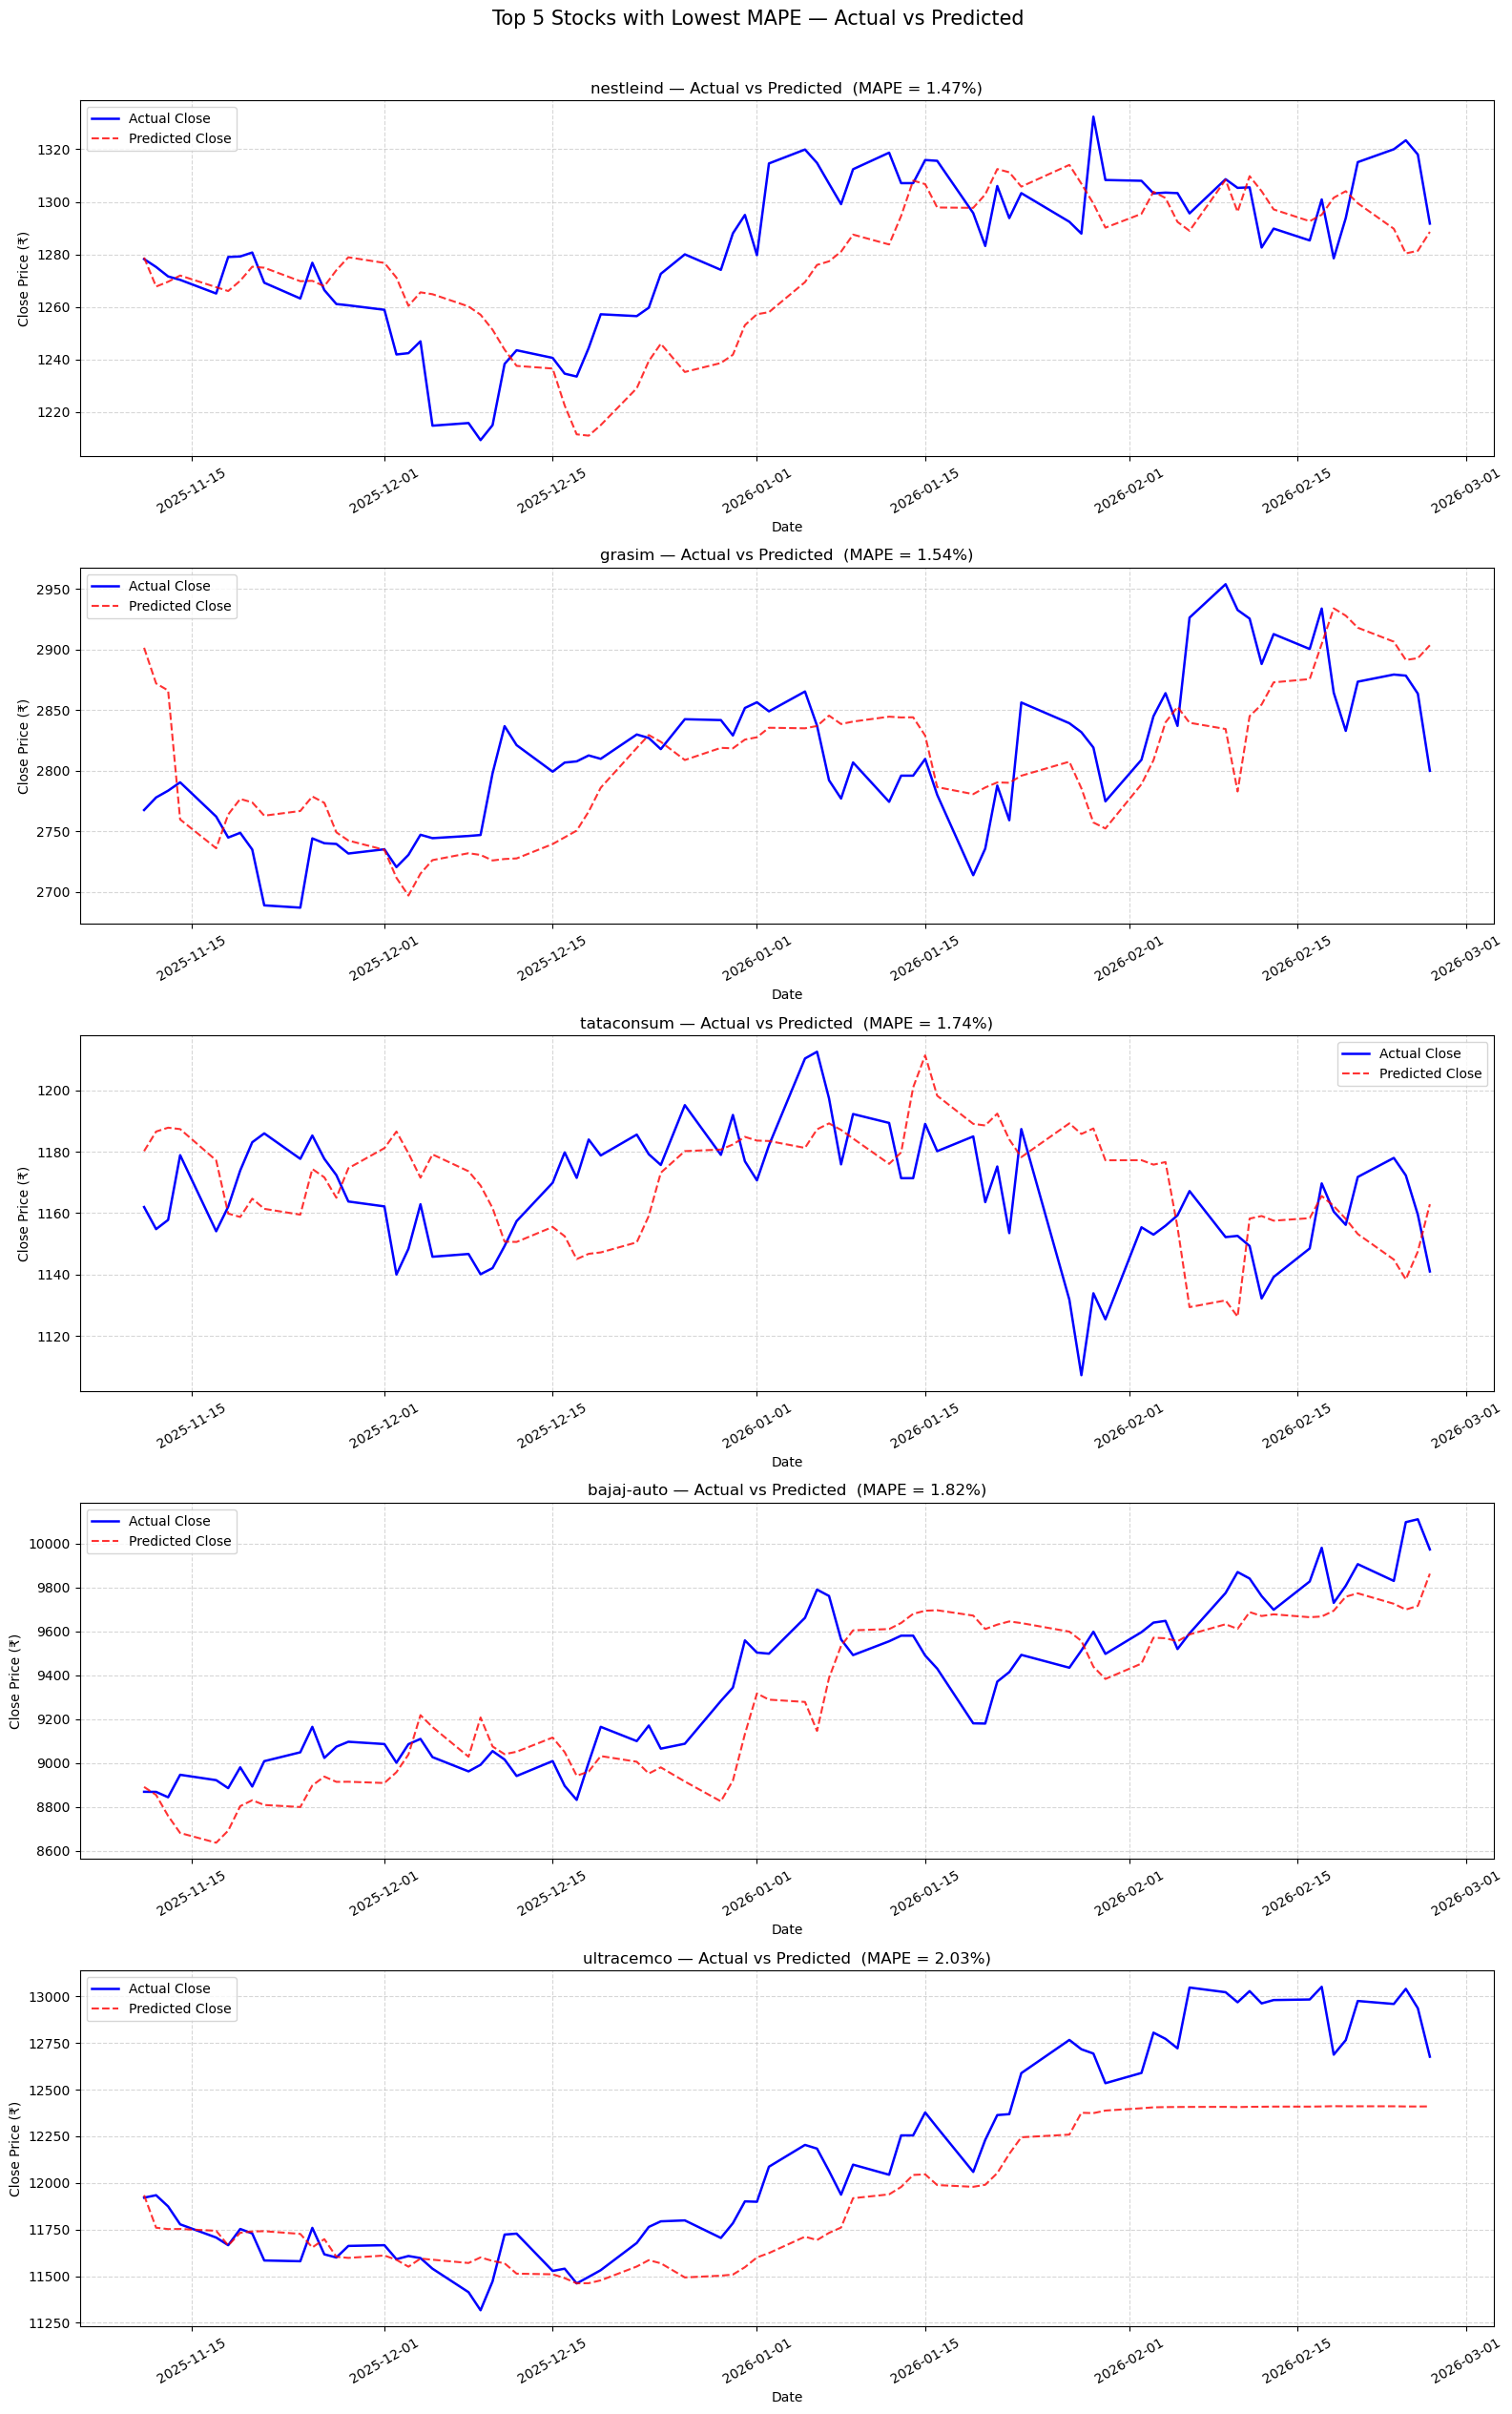


Metrics for top 5 (lowest MAPE):
  nestleind             MAPE =   1.47%   MAE =    18.82   RMSE =    24.04
  grasim                MAPE =   1.54%   MAE =    43.26   RMSE =    54.06
  tataconsum            MAPE =   1.74%   MAE =    20.23   RMSE =    24.81
  bajaj-auto            MAPE =   1.82%   MAE =   170.87   RMSE =   215.46
  ultracemco            MAPE =   2.03%   MAE =   253.44   RMSE =   319.05


In [124]:

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ══════════════════════════════════════════════════════════════════════
#  Per-Ticker MAPE → Plot 5 Stocks with Lowest MAPE
# ══════════════════════════════════════════════════════════════════════

# test_df retains Ticker & Date columns and its row order matches y_test / predictions
ticker_series = test_df['Ticker'].values
date_series   = pd.to_datetime(test_df['Date'].values)

per_ticker_df = pd.DataFrame({
    'Ticker':          ticker_series,
    'Date':            date_series,
    'Actual Close':    y_test_np.flatten(),
    'Predicted Close': predictions.flatten(),
})

# ── Calculate MAPE for each ticker ──
def ticker_mape(grp):
    return np.mean(np.abs((grp['Actual Close'] - grp['Predicted Close']) / grp['Actual Close'])) * 100

mape_per_ticker = per_ticker_df.groupby('Ticker').apply(ticker_mape).rename('MAPE (%)')
mape_df = mape_per_ticker.sort_values().reset_index()
mape_df.columns = ['Ticker', 'MAPE (%)']

print("MAPE for ALL tickers (sorted best → worst):")
display(mape_df)

# ── Top 5 tickers with lowest MAPE ──
best5 = mape_df.head(5)['Ticker'].tolist()
print(f"\nTop 5 tickers (lowest MAPE): {best5}")

# ── Plot each ticker on its own subplot ──
fig, axes = plt.subplots(5, 1, figsize=(16, 25), sharex=False)

for ax, ticker in zip(axes, best5):
    tk_df = per_ticker_df[per_ticker_df['Ticker'] == ticker].sort_values('Date').reset_index(drop=True)
    tk_mape = mape_df[mape_df['Ticker'] == ticker]['MAPE (%)'].values[0]

    ax.plot(tk_df['Date'], tk_df['Actual Close'],
            label='Actual Close', color='blue', linewidth=1.8)
    ax.plot(tk_df['Date'], tk_df['Predicted Close'],
            label='Predicted Close', color='red', linestyle='--', alpha=0.8)
    ax.set_title(f'{ticker} — Actual vs Predicted  (MAPE = {tk_mape:.2f}%)')
    ax.set_xlabel('Date')
    ax.set_ylabel('Close Price (₹)')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Top 5 Stocks with Lowest MAPE — Actual vs Predicted', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

# ── Summary table for best 5 ──
print("\nMetrics for top 5 (lowest MAPE):")
for ticker in best5:
    tk = per_ticker_df[per_ticker_df['Ticker'] == ticker]
    mae  = np.mean(np.abs(tk['Actual Close'] - tk['Predicted Close']))
    rmse = np.sqrt(np.mean((tk['Actual Close'] - tk['Predicted Close'])**2))
    mape_val = mape_df[mape_df['Ticker'] == ticker]['MAPE (%)'].values[0]
    print(f"  {ticker:20s}  MAPE = {mape_val:6.2f}%   MAE = {mae:8.2f}   RMSE = {rmse:8.2f}")
